# **Damage propagation in a U-bolt:**
In the following parts we will focus on the problem of damage propagation over time. In the following lines of code we will upload the data computed by solving a **F.O.M.**.
This high fidelity solutions are computed starting from the **Fisher-KPP** equation:
<br><br><br>
$$
\begin{cases}
\frac{\partial u}{\partial t} - D \Delta u = r u(1-u) & \text{in } \Omega \times (0,T], \\
\nabla u \cdot \mathbf{n} = 0 & \text{on } \partial \Omega \times (0,T], \\
u(\cdot, 0) = g_\delta & \text{in } \Omega,
\end{cases}
$$
<br><br><br>
where $D > 0$ and $r > 0$ are the **diffusion and reaction coefficients**, respectively, whereas $\delta > 0$ is a parameter describing the location of **the initial damage**. While, the solution $u : \Omega \times [0, T] \rightarrow [0, 1]$ indicates the level of damage:

*   $u$ equal to $1$ indicates maximum damage
*   $u$ equal to $0$ indicates no damage



 Then for $g_\delta$ we have that:


$$
g_\delta(x,y) :=
\begin{cases}
1 & \text{if } |x - \delta| < 0.1 \text{ and } y \geq 4, \\
0 & \text{otherwise}.
\end{cases}
$$


For the sake of our analysis, we parametrize the model coefficients as


$$
D = 10^{\mu_1}, \quad r = 10^{\mu_2 + 2}, \quad \delta = \mu_3 + 1,
$$


where $\mu = [\mu_1, \mu_2, \mu_3]^\top$ varies in $[0,1]^3$. The final time is set to $T = 0.02$.



In [1]:
import numpy as np
import matplotlib.pyplot as plt
try:
     from dlroms import*
except:
     !pip install --no-deps git+https://github.com/NicolaRFranco/dlroms.git
     from dlroms import*

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import svd
import time
from IPython.display import clear_output as clc
import torch
from torch import tanh
from torch.optim import Adam

In [2]:
# Fancy colormap for plotting
from matplotlib.colors import ListedColormap
import matplotlib as mpl
jet = mpl.colormaps['jet']
jet_colors = jet(np.linspace(0, 1, 256))
def modify_jet_to_gray(jet_colors):
    new_colors = jet_colors.copy()
    gray_vals = np.linspace(0.3, 0.7, 85)
    for i in range(85):
        new_colors[i, 0:3] = gray_vals[i]
    return ListedColormap(new_colors)
gray_jet = modify_jet_to_gray(jet_colors)

In [3]:
# FOM discretization
import gdown
gdown.download(id = "1_4uC_yjWmvaDfAuRt0I1PI3IENE4XYXX", output = "ubolt_mesh.xml")
mesh = fe.loadmesh("ubolt_mesh.xml")
Vh = fe.space(mesh, 'CG', 1)

Downloading...
From (original): https://drive.google.com/uc?id=1_4uC_yjWmvaDfAuRt0I1PI3IENE4XYXX
From (redirected): https://drive.google.com/uc?id=1_4uC_yjWmvaDfAuRt0I1PI3IENE4XYXX&confirm=t&uuid=bb15e5d3-4dfb-4a5f-a8e4-a55604bd8b19
To: /content/ubolt_mesh.xml
100%|██████████| 1.33M/1.33M [00:00<00:00, 14.2MB/s]

Calling FFC just-in-time (JIT) compiler, this may take some time.



Level 25:FFC:Calling FFC just-in-time (JIT) compiler, this may take some time.
INFO:FFC:Compiling element ffc_element_3801828c0f66b7190a7fd5819465b3d5b34b9149

INFO:FFC:Compiler stage 1: Analyzing element(s)
INFO:FFC:--------------------------------------
INFO:FFC:  
INFO:FFC:Compiler stage 1 finished in 0.00834703 seconds.

INFO:FFC:Compiler stage 2: Computing intermediate representation
INFO:FFC:-------------------------------------------------------
INFO:FFC:  Computing representation of 1 elements
DEBUG:FFC:  Reusing element from cache
DEBUG:FFC:  Reusing element from cache
INFO:FFC:  Computing representation of 1 dofmaps
DEBUG:FFC:  Reusing element from cache
INFO:FFC:  Computing representation of 0 coordinate mappings
INFO:FFC:  Computing representation of integrals
INFO:FFC:  Computing representation of forms
INFO:FFC:  
INFO:FFC:Compiler stage 2 finished in 0.388398 seconds.

INFO:FFC:Compiler stage 3: Optimizing intermediate representation
INFO:FFC:---------------------------

In [4]:
from google.colab import drive
drive.mount('/content/drive')

#now we load from the drive the dataset that we have already computed
#load_path = "/content/drive/MyDrive/Colab Notebooks/MODEL ORDER REDUCTION TECHNIQUES/ASSIGNEMENT_2/" #michele
load_path = "/content/drive/MyDrive/Colab Notebooks/ASSIGNEMENT_2/ASSIGNEMENT_2/" #mamma
mu = np.load(load_path + "mu.npy")
ufom = np.load(load_path + "ufom.npy")
clc()
print(f"The shape of the parameters, mu, is: {mu.shape}")
print(f"The shape of the uFom solution is: {ufom.shape}")
print(f"In particular:")
print(f"The number of simulation, Ns, is: {ufom.shape[0]}")
print(f"The number of time step per each simulation, Nt, is: {ufom.shape[1]}")
print(f"The number of mesh nodes, Nh, is: {ufom.shape[2]}")

The shape of the parameters, mu, is: (100, 3)
The shape of the uFom solution is: (100, 41, 6636)
In particular:
The number of simulation, Ns, is: 100
The number of time step per each simulation, Nt, is: 41
The number of mesh nodes, Nh, is: 6636


In [5]:
#we immediately pass to tensors
mu, ufom = dv.tensor(mu, ufom)

In [6]:
#we try to see how is the singular value decay even if we know that we will not use POD-GALERKIN
ntraining = 75
ntest = 25
Ns = ufom.shape[0] #the number of simulations
Nt = ufom.shape[1] #the number of time istances
Nh = ufom.shape[2] #the number of nodes
p = mu.shape[1] #the number of parameters
delta_t = 0.0005

In [7]:
l2 = L2(Vh) #we create the norm  and it expects input like ... x Nh
l2.cuda()
clc()

In [8]:
#now we define the error function that we will use several times in the code
def error_func(utrue, upred):
  #we must have data written as ... x Nh, otherwise L2 doesn't work
  current_Ns = utrue.shape[0]//Nt #because this will enter also in the training and there Ns is 75
  error =  (l2(utrue-upred).reshape(current_Ns, Nt)/l2(utrue).reshape(current_Ns, Nt)).mean(axis = -1)
  error = error.mean()
  return error

In [9]:
#POD-NN
ufom_PODNN = ufom.reshape(-1, Nh)
ntrain_PODNN = ntraining*Nt
t_final = 0.02
times_PODNN = torch.linspace(0, t_final, Nt)
mut_PODNN = torch.zeros(Ns, Nt, p + 1)

# Ciclo for usando solo tensori
for i in range(Ns):
    mut_PODNN[i, :, :p] = mu[i]
    mut_PODNN[i, :, p] = times_PODNN

mut_PODNN = mut_PODNN.reshape(-1, p+1)
mut_PODNN = dv.tensor(mut_PODNN)

/usr/local/lib/python3.11/dist-packages/dlroms/cores.py:56: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return ttensor(arrays[0], dtype = self.dtype, device = self.device)


In [10]:
#DL-ROM
ufom_DLRom = ufom.reshape(-1, Nh)
ntrain_DLRom = ntraining*Nt
t_final = 0.02
times_DLRom = torch.linspace(0, t_final, Nt)
mut_DLRom = torch.zeros(Ns, Nt, p + 1)

# Ciclo for usando solo tensori
for i in range(Ns):
    mut_DLRom[i, :, :p] = mu[i]
    mut_DLRom[i, :, p] = times_DLRom

mut_DLRom = mut_DLRom.reshape(-1, p+1)
mut_DLRom = dv.tensor(mut_DLRom)

In [11]:
#POD-AE-SINDy
ufom_PODAESindy = ufom.reshape(-1, Nh)
ntrain_PODAESindy = ntraining*Nt
t_final = 0.02
times_PODAESindy = torch.linspace(0, t_final, Nt)

# **Download of the neural networks:**
Now we download the pre-trained neural network. To appreciate theem we can also try to look at the error defined in this way:


$$
\quad
\frac{1}{N_{\text{test}}} \sum_{i=1}^{N_{\text{test}}}
\left[
\frac{1}{N_{\text{t}}} \sum_{j=1}^{N_{\text{t}}}
\frac{\| u_{\text{test}_{i,j}} - \tilde{u}_{\text{test}_{i,j}} \|_{L^2(\Omega)}}
{\| u_{\text{test}_{i,j}} \|_{L^2(\Omega)}}
\right]
$$

where:


*    $u_{test}$ is $u_{fom}$ for the test dataset
*   $\tilde{u}_{\text{test}}$ is $u_{rom}$ for the test dataset

# **POD-NN:**

In [12]:
#POD-NN
V_PODNN = torch.load(load_path + "V_PODNN.pt")
N_PODNN = np.load(load_path + "N_PODNN.npy")
V_PODNN = V_PODNN.cuda()
N_PODNN = int(N_PODNN)

phi_PODNN = DFNN(Dense(p+1, 128, gelu) + Dense(128, 128, gelu) + Dense(128, 128, gelu) + Dense(128, N_PODNN, activation = None))
phi_PODNN.He()

phi_PODNN.load_state_dict(torch.load(load_path + "phi_PODNN.pt"))
phi_PODNN.cuda()
phi_PODNN.freeze()

uROM_PODNN = phi_PODNN(mut_PODNN) @ V_PODNN.T
uROM_PODNN = uROM_PODNN.reshape(Ns, Nt, Nh).cuda()

In [13]:
print("POD MRE: %s" % num2p(error_func(ufom_PODNN[ntrain_PODNN:], ufom_PODNN[ntrain_PODNN:] @ V_PODNN @ V_PODNN.T)))
print("POD-NN MRE: %s" % num2p(error_func(ufom_PODNN[ntrain_PODNN:], phi_PODNN(mut_PODNN[ntrain_PODNN:]) @ V_PODNN.T)))
print("POD-NN MRE WITH SATURATION: %s" % num2p(error_func(ufom_PODNN[ntrain_PODNN:], torch.clamp(phi_PODNN(mut_PODNN[ntrain_PODNN:]) @ V_PODNN.T, 0.0, 1.0))))

POD MRE: 1.03%
POD-NN MRE: 4.74%
POD-NN MRE WITH SATURATION: 4.31%


torch.Size([4100, 6636])


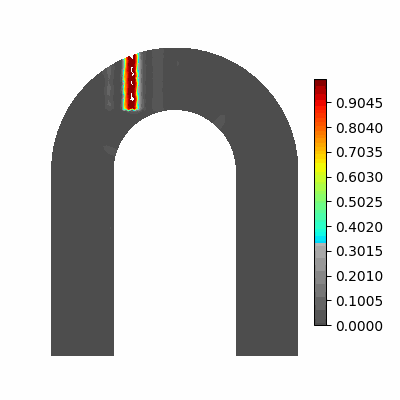

In [14]:
#ROM SOLUTION
#uROM_PODNN = phi_PODNN(mut_PODNN) @ V_PODNN.T
uROM_PODNN = torch.clamp(phi_PODNN(mut_PODNN) @ V_PODNN.T, 0.0, 1.0) #to see saturation
print(uROM_PODNN.shape)
uROM_PODNN = uROM_PODNN.reshape(Ns, Nt, Nh)
fe.animate(uROM_PODNN[98, :, :], Vh, cmap = gray_jet, colorbar = True)

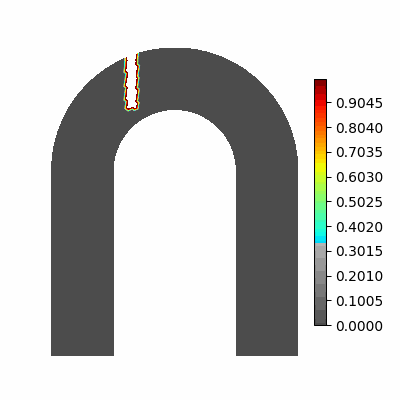

In [15]:
#FOM SOLUTION
fe.animate(ufom[98, :, :], Vh, cmap = gray_jet, colorbar = True)

# **DL-ROM:**

In [16]:
#DL-ROM
rho = lambda x: tanh(0.01*x) ### <-- smooth activation that bounds the dynamics within [-1,1]^n
rho_e = lambda x: relu(x) -10*relu(-x)
rho_d = lambda x: relu(x) -0.1*relu(-x)

latent = np.load(load_path + "latent_DLRom.npy")
latent = int(latent)
encoder_DLRom = Dense(Nh, 50, rho_e) + Dense(50, latent, rho)
decoder_DLRom = Dense(latent, 50, rho_d) + Dense(50, 500, rho_d) + Dense(500, Nh, activation = None)
ae_DLRom = DFNN(encoder_DLRom + decoder_DLRom)

ae_DLRom.load_state_dict(torch.load(load_path + "autoencoder_DLRom.pt"))
ae_DLRom.cuda()
ae_DLRom.freeze()

uLatent_DLRom = encoder_DLRom(ufom_DLRom)
phi_DLRom = DFNN(Dense(p + 1, 128, gelu) + Dense(128, 128, gelu) + Dense(128, 128, gelu) + Dense(128, latent, activation = None))
phi_DLRom.He()
phi_DLRom.load_state_dict(torch.load(load_path + "phi_DLRom.pt"))
phi_DLRom.cuda()
phi_DLRom.freeze()

uROM_DLRom = decoder_DLRom(phi_DLRom(mut_DLRom))
uROM_DLRom = uROM_DLRom.reshape(Ns, Nt, Nh).cuda()

In [17]:
print("Autoencoder MRE: %s" % num2p(error_func(ufom_DLRom[ntrain_DLRom:], ae_DLRom(ufom_DLRom[ntrain_DLRom:]))))
DLRom = lambda mt: decoder_DLRom(phi_DLRom(mt))
print("DL-ROM MRE: %s" % num2p(error_func(ufom_DLRom[ntrain_DLRom:], DLRom(mut_DLRom[ntrain_DLRom:]))))
print("DL-ROM MRE WITH SATURATION: %s" % num2p(error_func(ufom_DLRom[ntrain_DLRom:], torch.clamp( DLRom(mut_DLRom[ntrain_DLRom:]), 0.0, 1.0))))


Autoencoder MRE: 1.94%
DL-ROM MRE: 5.53%
DL-ROM MRE WITH SATURATION: 5.26%


torch.Size([4100, 6636])


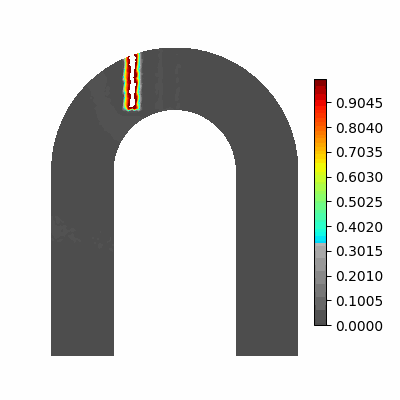

In [18]:
#ROM SOLUTION
#uROM_DLRom = DLRom(mut_DLRom)
uROM_DLRom = torch.clamp( DLRom(mut_DLRom), 0.0, 1.0) #to see the saturation
print(uROM_DLRom.shape)
uROM_DLRom = uROM_DLRom.reshape(Ns, Nt, Nh)
fe.animate(uROM_DLRom[98, :, :], Vh, cmap = gray_jet, colorbar = True)

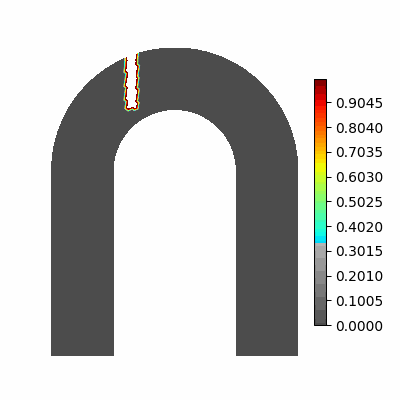

In [19]:
#FOM SOLUTION
fe.animate(ufom[98, :, :], Vh, cmap = gray_jet, colorbar = True)

# **POD-AE-SINDy:**

In [20]:
rho = lambda x: tanh(0.01*x) ### <-- smooth activation that bounds the dynamics within [-1,1]^n
V_PODAESindy = torch.load(load_path + "V_PODAESindy.pt")
N_PODAESindy = np.load(load_path + "N_PODAESindy.npy")
V_PODAESindy = V_PODAESindy.cuda()
N_PODAESindy = int(N_PODAESindy)
ufom_PODAESindy_reduced = ufom_PODAESindy @ V_PODAESindy
latent = p+1
small_encoder = Dense(N_PODAESindy, 40, gelu) + Dense(40, latent, rho)
small_decoder = Dense(latent, 40, gelu) + Dense(40, 100, gelu) + Dense(100, N_PODAESindy, activation = None)
small_ae = DFNN(small_encoder + small_decoder) ### <--- inner AE module, combining the "small encoder" and "small decoder"
small_ae.He()
small_ae.load_state_dict(torch.load(load_path + "small_ae_sindy.pt"))
small_ae.cuda()
small_ae.freeze()

from dlroms.dnns import Matrix
encoder = Matrix(V_PODAESindy.T) + small_encoder
decoder = small_decoder + Matrix(V_PODAESindy)
ae = encoder + decoder


In [21]:
from dlroms.dnns import Weightless
from torch import matmul

class Library(Weightless):
  def __init__(self, lib):
    super(Library, self).__init__()
    self.lib = lib

  def forward(self, x):
    from torch import cat
    nx = len(x)
    return cat([f(x).reshape(nx, -1) for f in self.lib], axis = -1)

class SINDy(ROM):
  def __init__(self, *args, **kwargs):
    from torch.nn import Parameter
    super(SINDy, self).__init__(*args, **kwargs)
    self.thr = Parameter(dv.tensor(0.0))

  def threshold(self, A0):
    # Hard-promotes sparsity by clamping values close to 0 (with a learnable threshold)
    return relu(A0-self.thr) - relu(-A0-self.thr)

  def A(self, mu):
    eta = self[0]
    A0 = eta(mu)
    return self.threshold(A0)

  def forward(self, mu, z):
    A = self.A(mu)
    theta = self.Xi(z).unsqueeze(-1)
    return matmul(A, theta).squeeze(-1), A

  def freeze(self, *args, **kwargs):
    super(SINDy, self).freeze(*args, **kwargs)
    self.thr.requires_grad_(False)

  def unfreeze(self, *args, **kwargs):
    super(SINDy, self).freeze(*args, **kwargs)
    self.thr.requires_grad_(True)

  def evolve(self, mu0, z0, steps, tau):
    from torch import atleast_2d
    mu0s = atleast_2d(mu0)
    z0s = atleast_2d(z0)

    many, n = z0s.shape
    zsindy = self.coretype().zeros(many, steps + 1, n)
    zsindy[:, 0] = z0s
    for j in range(steps):
      dzdtj = self.forward(mu0s, zsindy[:, j])[0]
      zsindy[:, j+1] = zsindy[:, j] + tau*dzdtj

    return zsindy

  def parameters(self, *args, **kwargs):
    return super(SINDy, self).parameters() + [self.thr]

  def He(self, *args, **kwargs):
    from torch.nn import Parameter
    super(SINDy, self).He(*args, **kwargs)
    self.thr = Parameter(dv.tensor(0.0))

In [22]:
def dt(zval):
  """Approximation of time derivatives via finite differences.
  Later used in the definition of the loss to approximate the true derivatives."""
  tau = 0.0005
  zprev = zval.reshape(-1, Nt, latent)[:, :-2, :].reshape(-1, latent)
  znext = zval.reshape(-1, Nt, latent)[:, 2: ,  :].reshape(-1, latent) ### <--- latent state at time instant "i+1", for each sample in the batch
  dzdt = (znext-zprev)/(2*tau)
  return dzdt

def sindy_loss(ztrue, sindy_output):
  dzpred, A = sindy_output
  dzdt_true = dt(ztrue) ### <-- time derivatives of the true latent coordinates
  return mse(euclidean)(dzdt_true, dzpred.reshape(-1, Nt, latent)[:, 1:-1].reshape(-1, latent)) + 0.01*A.abs().tanh().sum(axis = -1).sum(axis = -1).mean() # promotes sparsity via l1-penalty

def sindy_error(ztrue, sindy_output):
  dzpred, A = sindy_output
  dzdt_true = dt(ztrue) ### <-- time derivatives of the true latent coordinates
  return mse(euclidean)(dzdt_true, dzpred.reshape(-1, Nt, latent)[:, 1:-1].reshape(-1, latent))

In [23]:
from dlroms.dnns import Reshape
Xi = Library([lambda x: x, lambda x: x**2, lambda x:  x[:, 0]*x[:, 1], lambda x:  x[:, 1]*x[:, 2], lambda x:  x[:, 0]*x[:, 2],  lambda x:  x[:, 0]*x[:, 3],  lambda x:  x[:, 1]*x[:, 3],  lambda x:  x[:, 2]*x[:, 3], lambda x: 1.0 + 0*x])
#Xi = Library([lambda x: x, lambda x: x**2, lambda x: 1.0 + 0*x])

m = Xi(dv.zeros(1, latent)).shape[-1]
p = mu.shape[-1]

eta = Dense(p, 18, gelu) + Dense(18, m*latent, None) + Reshape(latent, m)
sindy = SINDy(eta, Xi = Xi)
sindy.He()
sindy.load_state_dict(torch.load(load_path + "sindy.pt"))
sindy.freeze()
sindy.cuda()

In [24]:
ztrue = encoder(ufom_PODAESindy).reshape(-1, Nt, latent)
z0s = ztrue[:, 0]
mu_repeated = (dv.zeros(Ns, Nt, 1) + mu.reshape(Ns, 1, -1)).reshape(Ns*Nt, -1)
zsindy = sindy.evolve(mu_repeated.reshape(Ns, Nt, -1)[:, 0], z0s, steps = Nt-1, tau = 0.0005)

torch.Size([4100, 6636])


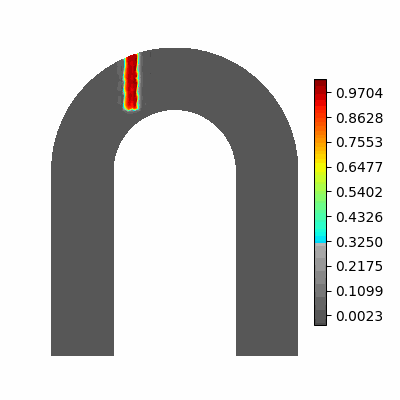

In [25]:
#ROM SOLUTION
uROM_AESindy = decoder(zsindy.reshape(Ns*Nt, -1))
#uROM_AESindy = torch.clamp(decoder(zsindy.reshape(Ns*Nt, -1)), 0.0, 1.0) #to see saturation
print(uROM_AESindy.shape)
uROM_AESindy = uROM_AESindy.reshape(Ns, Nt, Nh)
fe.animate(uROM_AESindy[98, :, :], Vh, cmap = gray_jet, colorbar = True) #if you want to see a completely wrong simulation is the 92

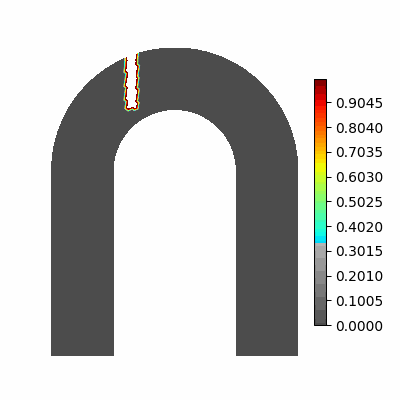

In [26]:
#FOM SOLUTION
fe.animate(ufom[98, :, :], Vh, cmap = gray_jet, colorbar = True)

In [27]:
#now we define the error function that we will use several times in the code

u_pred = uROM_AESindy[98, :, :].reshape(Nt, Nh)
u_pred_clamped = torch.clamp(uROM_AESindy[98, :, :].reshape(Nt, Nh), 0.0, 1.0)
u_true = ufom[98, :, :].reshape(Nt, Nh)
error_PODAESindy = (l2(u_true - u_pred)/l2(u_true)).mean()
error_PODAESindy_clamped = (l2(u_true - u_pred_clamped)/l2(u_true)).mean()

print("POD+AE MRE: %s" % num2p(error_func(ufom_PODAESindy[ntrain_PODAESindy:, :], ae(ufom_PODAESindy[ntrain_PODAESindy:, :])))) #ae_AESindy(ufom_AESindy[ntrain_AESindy:]))))
print(f"POD+AE+SINDy MRE on the 98-th simulation: {error_PODAESindy*100}%")
print(f"POD+AE+SINDy MRE on the 98-th simulation WITH SATURATION: {error_PODAESindy_clamped*100}%")

POD+AE MRE: 2.68%
POD+AE+SINDy MRE on the 98-th simulation: 9.109099388122559%
POD+AE+SINDy MRE on the 98-th simulation WITH SATURATION: 9.06624984741211%


<ipython-input-28-49ac8c0d3d26>:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=11, framealpha=0.9)


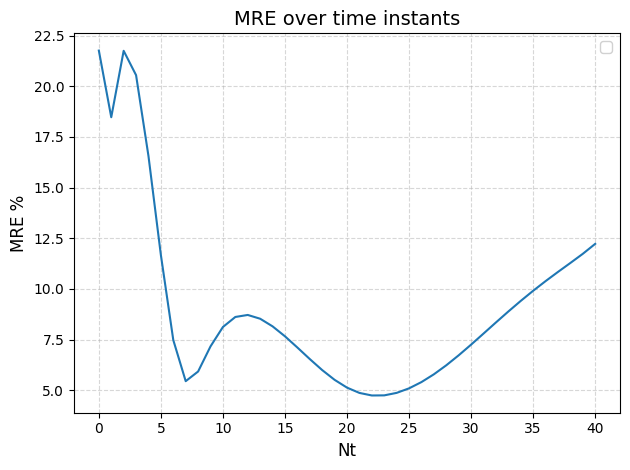

In [28]:
#To see where is the problem we can look at this error during time instants
error_time = (l2(u_true - u_pred)/l2(u_true))
plt.plot(np.arange(Nt), 100*error_time.detach().cpu().numpy())
# Labeling
plt.xlabel("Nt", fontsize=12)
plt.ylabel("MRE %", fontsize=12)
plt.title("MRE over time instants", fontsize=14)

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11, framealpha=0.9)
plt.tight_layout()
plt.show()
#indeed we can see that at the beginning we have a strangw colour

# **Comparisons:**
Now that we have all the 2 methods:


*   **POD-NN**
*   **DL-ROM**
*   **POD-AE-SINDy**

Now we look at different characteristics for having a cleaner idea about the 3 methods:


*   speed
*   ability to "predict the future"








In [29]:
from time import perf_counter
#SPEED
np.random.seed(42)

t_fom = 19.33

#POD-NN
mut_PODNN_speed = torch.zeros(1, Nt, p + 1)
mut_PODNN_speed[0, :, :p] = mu[98]
mut_PODNN_speed[0, :, p] = times_PODNN
mut_PODNN_speed = mut_PODNN_speed.reshape(-1, p+1)
mut_PODNN_speed = dv.tensor(mut_PODNN_speed)
#print(mu[idx_DLRom])
#print(mut_DLRom_speed)
t0 = perf_counter()
uROM_PODNN_speed = phi_PODNN(mut_PODNN_speed) @ V_PODNN.T
t1 = perf_counter()
dtROM_PODNN = t1 - t0
clc()
print(f"POD-NN evaluation time: {1000*dtROM_PODNN} milliseconds, that is {19.33//dtROM_PODNN} faster than FOM")

#DL-ROM
mut_DLRom_speed = torch.zeros(1, Nt, p + 1)
mut_DLRom_speed[0, :, :p] = mu[98]
mut_DLRom_speed[0, :, p] = times_DLRom
mut_DLRom_speed = mut_DLRom_speed.reshape(-1, p+1)
mut_DLRom_speed = dv.tensor(mut_DLRom_speed)
#print(mu[idx_DLRom])
#print(mut_DLRom_speed)
t0 = perf_counter()
uROM_DLRom_speed = decoder_DLRom(phi_DLRom(mut_DLRom_speed))
t1 = perf_counter()
dtROM_DLRom = t1 - t0
print(f"DL-ROM evaluation time: {1000*dtROM_DLRom} milliseconds, that is {19.33//dtROM_DLRom} faster than FOM")

#POD-AE-SINDY
mut_PODAESindy_speed = torch.zeros(1, Nt, p + 1)
mut_PODAESindy_speed[0, :, :p] = mu[98]
mut_PODAESindy_speed[0, :, p] = times_PODAESindy
mut_PODAESindy_speed = mut_PODAESindy_speed.reshape(-1, p+1)
mut_PODAESindy_speed = dv.tensor(mut_PODAESindy_speed)
t0 = perf_counter()
zsindy_speed = sindy.evolve(mut_PODAESindy_speed.reshape(1, Nt, -1)[:, 0, :p], z0s[98].unsqueeze(0), steps = Nt-1, tau = 0.0005) # Added unsqueeze(0)
uROM_PODAESindy_speed = decoder(zsindy_speed.reshape(1*Nt, -1)) # Reshape for decoder
t1 = perf_counter()
dtROM_PODAESindy = t1 - t0 # corrected variable name
print(f"POD-AE-SINDY evaluation time: {1000*dtROM_PODAESindy} milliseconds, that is {19.33//dtROM_PODAESindy} faster than FOM") # corrected variable name
#the speed of POD-NN and DL-ROM are almost the same and are

POD-NN evaluation time: 0.6728370000246287 milliseconds, that is 28729.0 faster than FOM
DL-ROM evaluation time: 1.5196780000223953 milliseconds, that is 12719.0 faster than FOM
POD-AE-SINDY evaluation time: 29.70804700004237 milliseconds, that is 650.0 faster than FOM


torch.Size([1, 81, 6636])


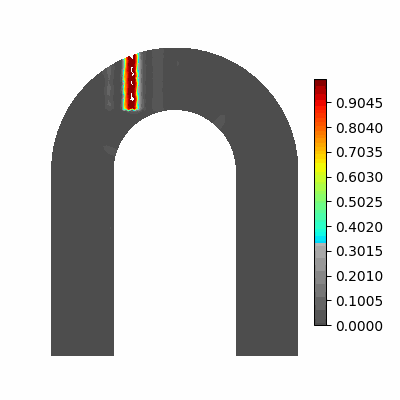

In [30]:
from os import times
#ERROR IN PREDICTING THE FUTURE

#POD-NN
t_final_new = 2*t_final
times_PODNN_new = torch.linspace(0, t_final_new, Nt*2-1) #because we don't have zero anymore so we have 41 + 40 points
mut_PODNN_new = torch.zeros(1, Nt*2-1, p + 1)

mut_PODNN_new[0, :, :p] = mu[98] #we select the last simulation
mut_PODNN_new[0, :, p] = times_PODNN_new
mut_PODNN_new = mut_PODNN_new.reshape(-1, p+1)
mut_PODNN_new = dv.tensor(mut_PODNN_new)

uROM_PODNN_new = phi_PODNN(mut_PODNN_new) @ V_PODNN.T

uROM_PODNN_new = uROM_PODNN_new.reshape(1, Nt*2-1, Nh)
uROM_PODNN_new_clamped = torch.clamp(uROM_PODNN_new, 0.0, 1.0)
print(uROM_PODNN_new.shape)
max_value_PODNN = uROM_PODNN_new.max()
fe.animate(uROM_PODNN_new_clamped[0, :, :], Vh, cmap=gray_jet, colorbar = True)


torch.Size([1, 81, 6636])


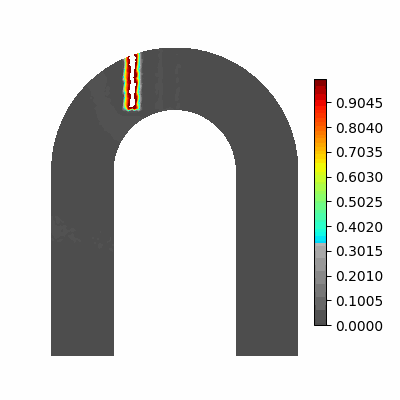

In [31]:
#ERROR IN PREDICTING THE FUTURE

#DL-ROM
t_final_new = 2*t_final
times_DLRom_new = torch.linspace(0, t_final_new, Nt*2-1) #because we don't have zero anymore so we have 41 + 40 points
mut_DLRom_new = torch.zeros(1, Nt*2-1, p + 1)

mut_DLRom_new[0, :, :p] = mu[98] #we select the last simulation
mut_DLRom_new[0, :, p] = times_DLRom_new
#print(mut_DLRom_new)
mut_DLRom_new = mut_DLRom_new.reshape(-1, p+1)
mut_DLRom_new = dv.tensor(mut_DLRom_new)

uROM_DLRom_new =decoder_DLRom(phi_DLRom(mut_DLRom_new))

uROM_DLRom_new = uROM_DLRom_new.reshape(1, Nt*2-1, Nh)
uROM_DLRom_new_clamped = torch.clamp(uROM_DLRom_new, 0.0, 1.0)
print(uROM_DLRom_new.shape)
max_value_DLRom = uROM_DLRom_new.max()
fe.animate(uROM_DLRom_new_clamped[0, :, :], Vh, cmap=gray_jet, colorbar = True)


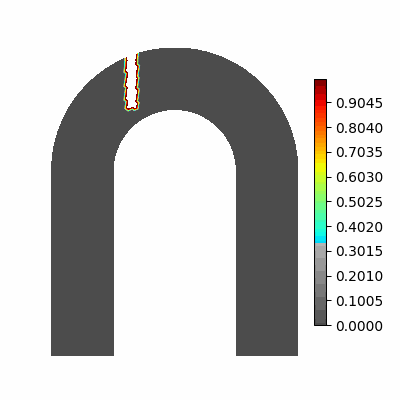

In [32]:
fe.animate(ufom[98, :, :], Vh, cmap = gray_jet, colorbar = True)

In [33]:
#ERROR IN PREDICTING THE FUTURE

#POD-AE-SINDy
#t_final_new = 2*t_final
#times_PODAESindy_new = torch.linspace(0, t_final_new, Nt*2-1) #because we don't have zero anymore so we have 41 + 40 points
#mut_PODAESindy_new = torch.zeros(1, Nt*2-1, p + 1)

#mut_PODAESindy_new[0, :, :p] = mu[98] #we select the last simulation
#mut_PODAESindy_new[0, :, p] = times_PODAESindy_new
#print(mut_DLRom_new)
#mut_PODAESindy_new = mut_PODAESindy_new.reshape(-1, p+1)
#mut_PODAESindy_new = dv.tensor(mut_PODAESindy_new)

#zsindy_new = sindy.evolve(mut_PODAESindy_new.reshape(1, 2*Nt-1, -1)[:, 0, :p], z0s[98].unsqueeze(0), steps = 2*Nt-1-1, tau = 0.0005) # Added unsqueeze(0)
#uROM_PODAESindy_new = decoder(zsindy_new.reshape(1*(Nt*2-1), -1)) # Reshape for decoder

#uROM_PODAESindy_new = uROM_PODAESindy_new.reshape(1, Nt*2-1, Nh)
#uROM_PODAESindy_new_clamped = torch.clamp(uROM_PODAESindy_new, 0.1, 1.0)
#print(uROM_PODAESindy_new.shape)

#fe.animate(uROM_PODAESindy_new_clamped[0, :, :], space=Vh, cmap=gray_jet)


# **Now we compute the functional $J$:**
$$
J(u) := \frac{1}{T} \int_0^T \int_{\Omega} u(x, t) \, dx \, dt
$$

This is a quantity which represents the overall damage, averaged over time. We have to compute the "true" value from the **F.O.M.** and then we compare this value with the values coming from the **R.O.M.**s that we have prepared in the previous steps.


In [34]:
from dlroms.minns import Integral

space_integral = Integral(Vh)

def J(u):
  u_cpu = u.cpu()
  return space_integral(u_cpu).reshape(-1, Nt).mean(axis = -1)


In [35]:
# FOM
ufom_cuda = ufom.cuda()
J_fom = J(ufom_cuda[ntraining:, :, :])
print(J_fom.shape)

torch.Size([25])


In [36]:
#POD-NN
J_PODNN = J(uROM_PODNN[ntraining:, :, :])

In [37]:
#DL-ROM
J_DLRom = J(uROM_DLRom[ntraining:, :, :])

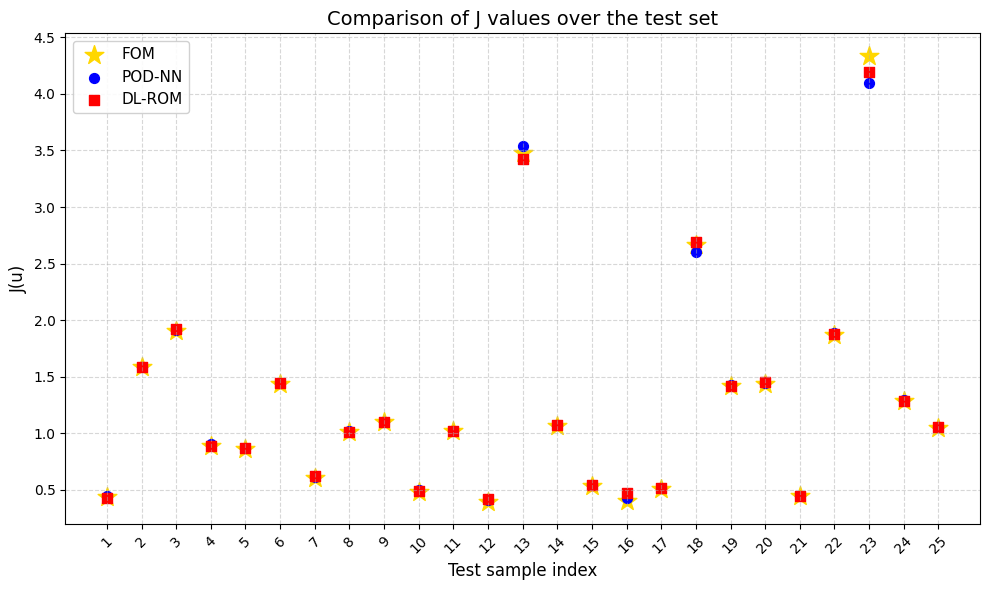

In [38]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(1, 26)  # 25 punti equispaziati da 1 a 25

plt.figure(figsize=(10, 6))  # Aumenta dimensione grafico

plt.scatter(x, J_fom, marker='*', color='gold', s=200, label="FOM")
plt.scatter(x, J_PODNN, marker='o', color='blue', s=50, label="POD-NN")
plt.scatter(x, J_DLRom, marker='s', color='red', s=50, label="DL-ROM")

plt.xlabel("Test sample index", fontsize=12)
plt.ylabel("J(u)", fontsize=12)
plt.title("Comparison of J values over the test set", fontsize=14)

plt.xticks(x, rotation=45)  # Mostra ogni punto con rotazione
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='best', fontsize=11, framealpha=0.9)
plt.tight_layout()
plt.show()


In [39]:
#To see the real difference between the functionals we can compute the error:

error_J_PODNN = (abs(J_fom - J_PODNN)/abs(J_fom)).mean()
error_J_DLRom = (abs(J_fom - J_DLRom)/abs(J_fom)).mean()
print(f"POD-NN error: {error_J_PODNN*100}%")
print(f"DL-ROM error: {error_J_DLRom*100}%")

POD-NN error: 1.5682673454284668%
DL-ROM error: 1.8047949075698853%


# **Exploiting the R.O.M.:**
Now that we have seen that the **R.O.M.**s are reliable, we can exploit them to make very cheap computation. For example we can see how the functional $J$ changing the parameters: In particular:


*   $D =\sqrt{10}$ ---> so $\mu_1 = 0.5$ (constant diffusion of the damage)
*   $100\leq r \leq1000$ ---> so $0\leq \mu_2 \leq1$ (local effect)
*   $\delta \in\ [{1, 1.5, 2}]$ ---> so $\mu_3 \in\ [{0, 0.5, 1}]$ (initial position)

The request is to plot the values of $J$ in function of $\log_{10}(r)$.

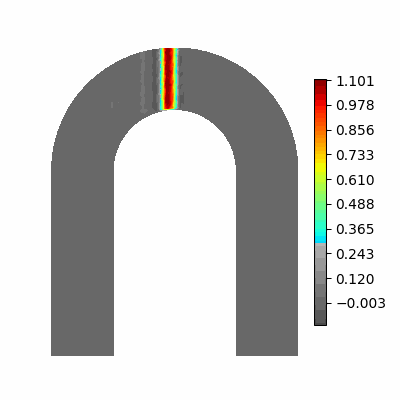

In [40]:
#plots to understand better the parameters
mut_PODNN_try = torch.zeros(1, Nt, p + 1)
mu_try = np.array([0.5, 0.5, 0.9])
mu_try = dv.tensor(mu_try)
mut_PODNN_try[0, :, :p] = mu_try
mut_PODNN_try[0, :, p] = times_DLRom
mut_PODNN_try = mut_PODNN_try.reshape(-1, p+1)
mut_PODNN_try = dv.tensor(mut_PODNN_try)
#print(mu[idx_DLRom])
#print(mut_DLRom_speed)

V_PODNN_cuda = V_PODNN.cuda()
uROM_PODNN_try = phi_PODNN(mut_PODNN_try) @ V_PODNN.T
uROM_PODNN_try = uROM_PODNN_try.reshape(1, Nt, Nh)
fe.animate(uROM_PODNN_try[0,:,:], Vh, cmap=gray_jet, colorbar = True)

#if I increase mu1 I have a faster diffusion of the damage
#if I increase mu2 I have that locally I need less time to have a bigger damage, locally becomes red faster
#for smal mu3 the initial damage is more on the left, as long as we increase mu3 the damage moves towards right

In [41]:
#now we create the new parameters for the new simulation
mu1 = 0.5
mu2 = np.linspace(0, 1, 100)
mu3 = np.array([0, 0.5, 1])
mu1, mu2, mu3 = dv.tensor(mu1, mu2, mu3)


#1-st so only for mu3 = 0
mut_J1 = torch.zeros(mu2.shape[0], Nt, p + 1)
for i in range(mu2.shape[0]):
    mut_J1[i, :, 0] = mu1
    mut_J1[i, :, 1] = mu2[i]
    mut_J1[i, :, 2] = mu3[0]
    mut_J1[i, :, 3] = times_PODNN

mut_J1 = mut_J1.cuda()


#2-nd so only for mu3 = 0.5
mut_J2 = torch.zeros(mu2.shape[0], Nt, p + 1)
for i in range(mu2.shape[0]):
    mut_J2[i, :, 0] = mu1
    mut_J2[i, :, 1] = mu2[i]
    mut_J2[i, :, 2] = mu3[1]
    mut_J2[i, :, 3] = times_PODNN

mut_J2 = mut_J2.cuda()


#3-rd so only for mu3 = 1
mut_J3 = torch.zeros(mu2.shape[0], Nt, p + 1)
for i in range(mu2.shape[0]):
    mut_J3[i, :, 0] = mu1
    mut_J3[i, :, 1] = mu2[i]
    mut_J3[i, :, 2] = mu3[2]
    mut_J3[i, :, 3] = times_PODNN

mut_J3 = mut_J3.cuda()


In [42]:
#let's compute with both the POD-NN and DL-ROM the result

#POD-NN
V_PODNN_cuda = V_PODNN.cuda()
uROM_PODNN_J1 = phi_PODNN(mut_J1) @ V_PODNN.T
uROM_PODNN_J1 = uROM_PODNN_J1.reshape(-1, Nt, Nh)
J1_PODNN_new = J(uROM_PODNN_J1)

uROM_PODNN_J2 = phi_PODNN(mut_J2) @ V_PODNN.T
uROM_PODNN_J2 = uROM_PODNN_J2.reshape(-1, Nt, Nh)
J2_PODNN_new = J(uROM_PODNN_J2)

uROM_PODNN_J3 = phi_PODNN(mut_J3) @ V_PODNN.T
uROM_PODNN_J3 = uROM_PODNN_J3.reshape(-1, Nt, Nh)
J3_PODNN_new = J(uROM_PODNN_J3)

#DL-ROM
uROM_DLRom_J1 = decoder_DLRom(phi_DLRom(mut_J1))
uROM_DLRom_J1 = uROM_DLRom_J1.reshape(-1, Nt, Nh)
J1_DLRom_new = J(uROM_DLRom_J1)

uROM_DLRom_J2 = decoder_DLRom(phi_DLRom(mut_J2))
uROM_DLRom_J2 = uROM_DLRom_J2.reshape(-1, Nt, Nh)
J2_DLRom_new = J(uROM_DLRom_J2)

uROM_DLRom_J3 = decoder_DLRom(phi_DLRom(mut_J3))
uROM_DLRom_J3 = uROM_DLRom_J3.reshape(-1, Nt, Nh)
J3_DLRom_new = J(uROM_DLRom_J3)

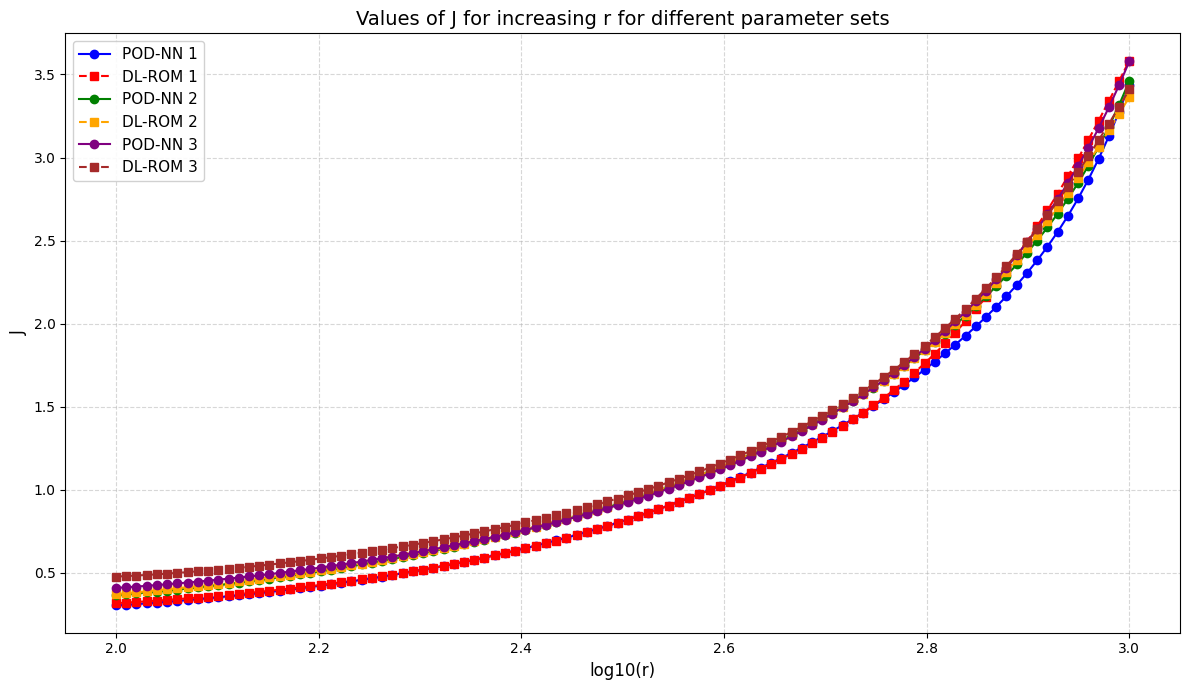

In [43]:
plt.figure(figsize=(12, 7))

# Calcolo r e log10(r)
mu2_safe = torch.where(mu2 == 0, 1e-10, mu2)
r = 10**(mu2 + 2)
r_log = torch.log10(r)

# Plot per J1
plt.plot(r_log.cpu().numpy(), J1_PODNN_new.cpu().numpy(), 'o-', color='blue', label="POD-NN 1")
plt.plot(r_log.cpu().numpy(), J1_DLRom_new.cpu().numpy(), 's--', color='red', label="DL-ROM 1")

# Plot per J2
plt.plot(r_log.cpu().numpy(), J2_PODNN_new.cpu().numpy(), 'o-', color='green', label="POD-NN 2")
plt.plot(r_log.cpu().numpy(), J2_DLRom_new.cpu().numpy(), 's--', color='orange', label="DL-ROM 2")

# Plot per J3
plt.plot(r_log.cpu().numpy(), J3_PODNN_new.cpu().numpy(), 'o-', color='purple', label="POD-NN 3")
plt.plot(r_log.cpu().numpy(), J3_DLRom_new.cpu().numpy(), 's--', color='brown', label="DL-ROM 3")

# Labeling
plt.xlabel("log10(r)", fontsize=12)
plt.ylabel("J", fontsize=12)
plt.title("Values of J for increasing r for different parameter sets", fontsize=14)

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11, framealpha=0.9)
plt.tight_layout()
plt.show()


# **Conclusion:**
Now that we have seen the results we can start making some comclusions:

**Training Time:**
*   **POD-NN**: very short training for phi
*   **DL-ROM**:very long training for the autoencoder
*   **POD-AE-SINDy**:very long training for the autoencoder and short training for $\eta$

**Speed ranking:**

1.   **POD-NN**
2.   **DL-ROM**
3.   **POD-AE-SINDy**

**Error on snapshots**:
*   **POD-NN**: small error
*   **DL-ROM**: error slightly bigger than POD-NN but comparable
*   **POD-AE-SINDy**: extremely high error

**Error on J**:
*   **POD-NN**: small error
*   **DL-ROM**: error slightly bigger than POD-NN but comparable
*   **POD-AE-SINDy**: none

At the end we can conclude that for this problem **POD-NN** works well. It simple and with only one neural network. The decay of the singular values of the snapshots matrix is good and so I cannot see any reason for not using this method. The only problem is that if we want to predict what happens outside the training time we will not obtain a good result.



